In [2]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [4]:
df_default = pd.read_csv('experiment_metrics_fully_parallel/default1.csv')
df_default['Model size'] = '6M'

df2 = pd.read_csv('experiment_metrics_fully_parallel/param-4M.csv')
df2['Model size'] = '4M'

df3 = pd.read_csv('experiment_metrics_fully_parallel/param-1M.csv')
df3['Model size'] = '1M'

mdf = pd.concat([df_default, df2, df3], ignore_index=True)
print(mdf.columns)

Index(['val/total_mse', 'train/grad_norm', 'train/forces_magnitude_error',
       'train/lr', 'train/epoch', 'train/energy_mae', '_timestamp',
       'val/forces_mae', 'val/energy_mse', 'train/forces_mse',
       'train/energy_rmse', 'train/energy_forces_within_threshold',
       'val/forces_rmse', 'val/energy_mae', 'train/energy_mse',
       'val/energy_rmse', 'val/forces_cosine_similarity',
       'train/forces_cosine_similarity', 'train/step',
       'val/pct_loss_from_equiv_error', '_runtime', 'train/forces_mae',
       'val/loss', 'val/mean_pred_error', 'val/epoch',
       'val/energy_forces_within_threshold', 'train/loss', 'val/forces_mse',
       'val/forces_magnitude_error', 'train/forces_rmse', '_step',
       'val/equiv_error', 'Model size', 'val/mean_pred_grad_norm',
       'val/equiv_grad_norm', 'val/grad_norm_ratio_equiv_over_mean'],
      dtype='object')


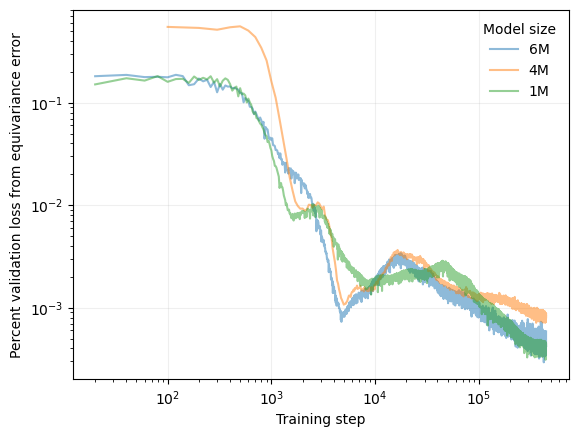

In [5]:
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/pct_loss_from_equiv_error',
    hue = 'Model size',
    errorbar = None,
    alpha=0.5,
)

plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)
plt.xlabel('Training step')
plt.ylabel('Percent validation loss from equivariance error')
plt.legend(frameon=False, title = 'Model size')

plt.savefig('escaip-vary-model-size.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()